# 📊 Web Analytics — Traffic, Engagement & Channel Performance Analysis

> **Dataset:** Google Analytics Export — `web_data_analysis.csv`  
> **Author:** Data Analysis Notebook  
> **Goal:** Understand how different traffic channels perform across time, and identify patterns in user engagement, session quality, and hourly traffic distribution.

---

## 🗂️ Table of Contents

1. [Import Libraries](#1-import-libraries)
2. [Load & Inspect the Dataset](#2-load--inspect-the-dataset)
3. [Data Cleaning & Preprocessing](#3-data-cleaning--preprocessing)
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis)
   - 4.1 [Sessions & Users Over Time](#41-sessions--users-over-time)
   - 4.2 [Total Users by Channel](#42-total-users-by-channel)
   - 4.3 [Average Engagement Time by Channel](#43-average-engagement-time-by-channel)
   - 4.4 [Engagement Rate Distribution by Channel](#44-engagement-rate-distribution-by-channel)
   - 4.5 [Engaged vs Non-Engaged Sessions](#45-engaged-vs-non-engaged-sessions)
   - 4.6 [Traffic Heatmap — Hour × Channel](#46-traffic-heatmap--hour--channel)
   - 4.7 [Engagement Rate vs Sessions Over Time](#47-engagement-rate-vs-sessions-over-time)
5. [Key Insights & Recommendations](#5-key-insights--recommendations)

---

## 1. Import Libraries

We begin by importing all necessary libraries:
- **NumPy** — numerical computations and aggregation functions
- **Pandas** — data loading, manipulation, and transformation
- **Matplotlib** — base plotting engine
- **Seaborn** — high-level statistical visualizations built on Matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


---

## 2. Load & Inspect the Dataset

The dataset is a Google Analytics export containing hourly traffic data broken down by **Channel Group** (e.g. Organic Search, Direct, Referral, etc.). Each row represents a specific channel's activity for a given hour.

We load the raw CSV and take a first look at its structure.

In [2]:
df = pd.read_csv("web_data_analysis.csv")
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.52666667,0.607594937,4.673333333,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737828,0.634615385,4.29588015,0.494382022,1147
3,Direct,2024041723,188,233,115,39.93991416,0.611702128,4.587982833,0.493562232,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.668449198,4.078125,0.48828125,1044


> **Observation:** The raw file has the actual column names stored in the *first data row*, not in the header. This is a common issue with Google Analytics CSV exports. We'll fix this in the next section.

---

## 3. Data Cleaning & Preprocessing

Raw exports from analytics platforms often require several cleaning steps before analysis can begin. Here we perform the following:

### Step 3.1 — Fix the Header Row

The first row of data contains the true column names. We promote it to the header and drop it from the data.

In [3]:
# Promote first row to column names
df.columns = df.iloc[0]
df = df.drop(index=0).reset_index(drop=True)
df.head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.52666667,0.607594937,4.673333333,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737828,0.634615385,4.29588015,0.494382022,1147
2,Direct,2024041723,188,233,115,39.93991416,0.611702128,4.587982833,0.493562232,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.668449198,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.91855204,0.64,4.529411765,0.50678733,1001


### Step 3.2 — Rename Columns for Clarity

The exported Google Analytics data can have inconsistent or overly complex column names. In this step, we rename them to make them simpler and easier to work with during analysis.

In [4]:
df.columns = [
    "Channel Group",
    "DateHour",
    "Users",
    "Sessions",
    "Engaged Sessions",
    "Avg Engagement Time Per session",
    "Engaged Session Per User",
    "Events Per Session",
    "Engagement Rate",
    "Event Count"
]
df.head()

,Channel Group,DateHour,Users,Sessions,Engaged Sessions,Avg Engagement Time Per session,Engaged Session Per User,Events Per Session,Engagement Rate,Event Count
0,Direct,2024041623,237,300,144,47.52666667,0.607594937,4.673333333,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737828,0.634615385,4.29588015,0.494382022,1147
2,Direct,2024041723,188,233,115,39.93991416,0.611702128,4.587982833,0.493562232,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.668449198,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.91855204,0.64,4.529411765,0.50678733,1001


### Step 3.3 — Parse the DateHour Column

The `DateHour` field is stored as an integer in `YYYYMMDDHH` format (e.g. `2024010109` = Jan 1 2024, 09:00). We parse it into a proper `datetime` object so we can work with it as a time series.

In [5]:
df["DateHour"] = pd.to_datetime(
    df["DateHour"].astype(str),
    format="%Y%m%d%H",
    errors="coerce"
)
df.head()

,Channel Group,DateHour,Users,Sessions,Engaged Sessions,Avg Engagement Time Per session,Engaged Session Per User,Events Per Session,Engagement Rate,Event Count
0,Direct,2024-04-16 23:00:00,237,300,144,47.52666667,0.607594937,4.673333333,0.48,1402
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.09737828,0.634615385,4.29588015,0.494382022,1147
2,Direct,2024-04-17 23:00:00,188,233,115,39.93991416,0.611702128,4.587982833,0.493562232,1069
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.16015625,0.668449198,4.078125,0.48828125,1044
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.91855204,0.64,4.529411765,0.50678733,1001


### Step 3.4 — Convert Numeric Columns & Extract Hour

All metric columns (Users, Sessions, Engagement Rate, etc.) were loaded as strings. We convert them to numeric types, coercing any invalid values to `NaN`. We also extract the **hour of day** as a separate feature — this will be critical for the hourly traffic heatmap.

In [6]:
numeric_cols = df.columns.drop(["Channel Group", "DateHour"])
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df["hour"] = df["DateHour"].dt.hour
df.head()

,Channel Group,DateHour,Users,Sessions,Engaged Sessions,Avg Engagement Time Per session,Engaged Session Per User,Events Per Session,Engagement Rate,Event Count,hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
3,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
4,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20


### Step 3.5 — Schema & Descriptive Statistics

Let's inspect data types and check for any obvious issues like nulls or unexpected ranges.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Channel Group                    3182 non-null   object        
 1   DateHour                         3182 non-null   datetime64[ns]
 2   Users                            3182 non-null   int64         
 3   Sessions                         3182 non-null   int64         
 4   Engaged Sessions                 3182 non-null   int64         
 5   Avg Engagement Time Per session  3182 non-null   float64       
 6   Engaged Session Per User         3182 non-null   float64       
 7   Events Per Session               3182 non-null   float64       
 8   Engagement Rate                  3182 non-null   float64       
 9   Event Count                      3182 non-null   int64         
 10  hour                             3182 non-null   int32      

In [8]:
df.describe()

,DateHour,Users,Sessions,Engaged Sessions,Avg Engagement Time Per session,Engaged Session Per User,Events Per Session,Engagement Rate,Event Count,hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


> **Observations from Summary Statistics:**
-Engagement Rate is expected to be a value between 0 and 1. Any value above 1 may indicate a data normalization issue during export.
-The Avg Engagement Time per session is recorded in seconds, so converting it into minutes makes it more readable.
-Null counts (from info()) help identify columns where parsing errors occurred — these rows represent problematic records and should be reviewed.

---

## 4. Exploratory Data Analysis

With clean data in hand, we now visualize the dataset from multiple angles to uncover patterns and insights.

### 4.1 Sessions & Users Over Time

“This graph shows how Sessions and Users vary over time on an hourly basis. It helps us understand overall traffic trends, spot sudden spikes or drops, and observe the gap between Sessions and Users, which indicates that users may be visiting the site multiple times.”

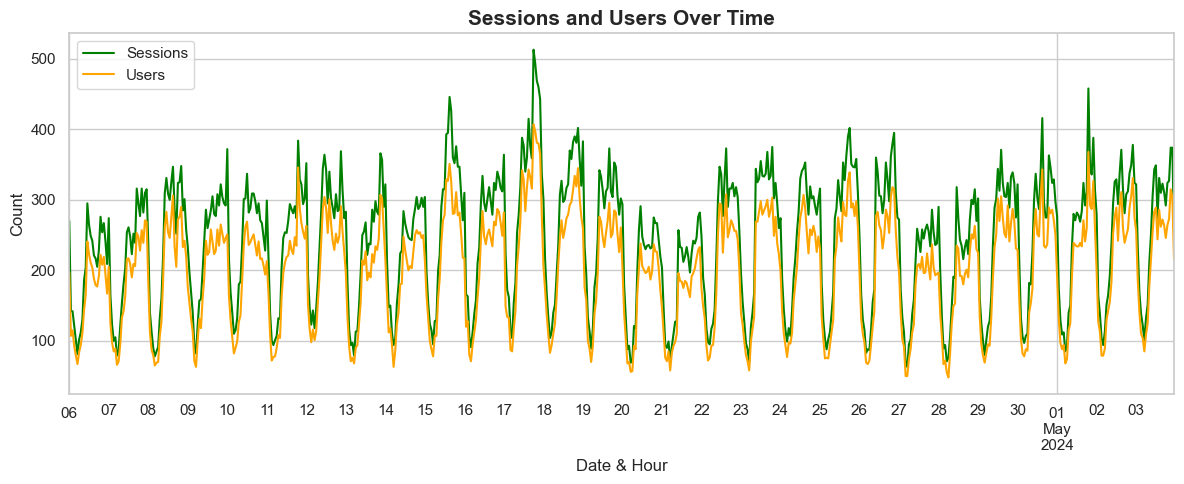

In [9]:
sns.set(style="whitegrid")

plt.figure(figsize=(12, 5))
df.groupby("DateHour")[["Sessions", "Users"]].sum().plot(
    ax=plt.gca(),
    color=["green", "orange"]
)
plt.title("Sessions and Users Over Time", fontsize=15, fontweight='bold')
plt.xlabel("Date & Hour")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

> **Insight:** When Sessions consistently exceed Users by a large margin, it means individual users are returning multiple times — a positive signal for content stickiness. Sharp peaks indicate either a traffic campaign or viral moment, while sudden drops may point to tracking outages or seasonality effects.

### 4.2 Total Users by Channel

This bar chart compares the **total user volume** brought in by each traffic channel. It directly answers: *Which channel drives the most visitors to the site?*

Understanding channel contribution helps teams prioritize marketing spend and SEO efforts.

C:\Users\tanve\AppData\Local\Temp\ipykernel_62884\1967959666.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


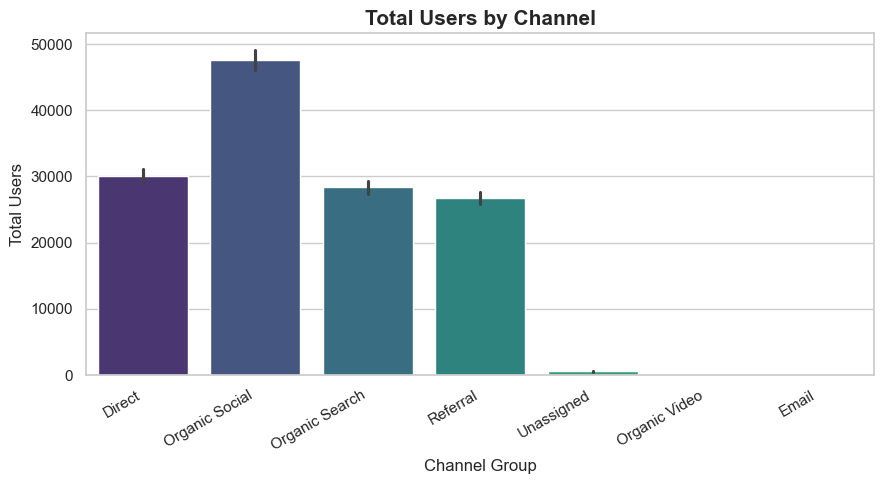

In [19]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df,
    x="Channel Group",
    y="Users",
    estimator=np.sum,
    palette="viridis"
  
)
plt.title("Total Users by Channel", fontsize=15, fontweight='bold')
plt.xlabel("Channel Group")
plt.ylabel("Total Users")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

> **Insight:** The tallest bars reveal your dominant acquisition channels. A channel with high user volume but low engagement (seen in later charts) may be driving low-quality traffic — quantity ≠ quality. Organic Search typically dominates healthy websites, while a heavy reliance on Direct traffic may indicate strong brand recall.

### 4.3 Average Engagement Time by Channel

Volume alone doesn't tell the full story. This chart measures the **average time users spend per session** for each channel, revealing *quality* of traffic rather than quantity.

A channel that sends fewer users but keeps them engaged longer is often more valuable than a high-volume, low-engagement source.

C:\Users\tanve\AppData\Local\Temp\ipykernel_62884\2199049115.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


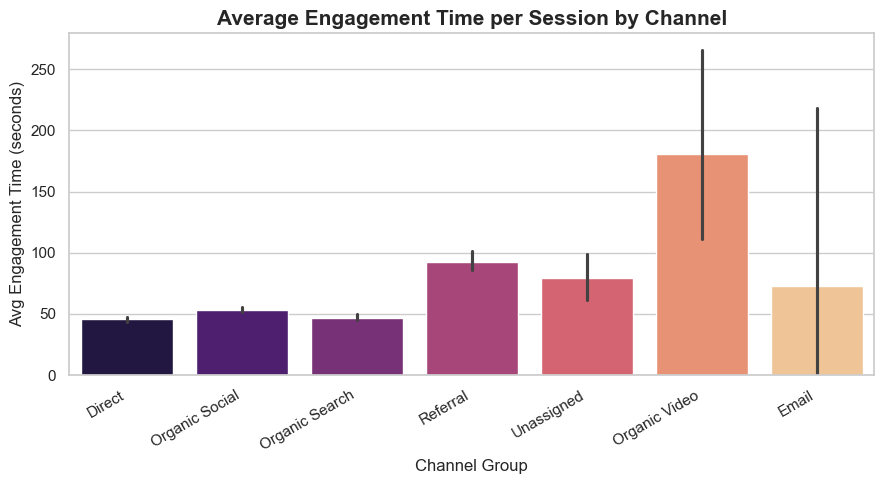

In [11]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df,
    x="Channel Group",
    y="Avg Engagement Time Per session",
    estimator=np.mean,
    palette="magma"
)
plt.title("Average Engagement Time per Session by Channel", fontsize=15, fontweight='bold')
plt.xlabel("Channel Group")
plt.ylabel("Avg Engagement Time (seconds)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

> **Insight:** Channels like Email or Organic Search often show higher engagement times because users arrive with intent. Channels like Display Ads or Social may show lower times, indicating passive or accidental clicks. This metric is key for content strategy — if even your top channels have low engagement time, it may signal a landing page or content relevance problem.

### 4.4 Engagement Rate Distribution by Channel

A boxplot shows the **distribution of Engagement Rate** across hours for each channel — not just the average, but also spread, outliers, and consistency.

In Google Analytics 4 (GA4), Engagement Rate = Engaged Sessions / Total Sessions. An engaged session lasts > 10 seconds, has a conversion event, or has 2+ page views.

C:\Users\tanve\AppData\Local\Temp\ipykernel_62884\1073885035.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


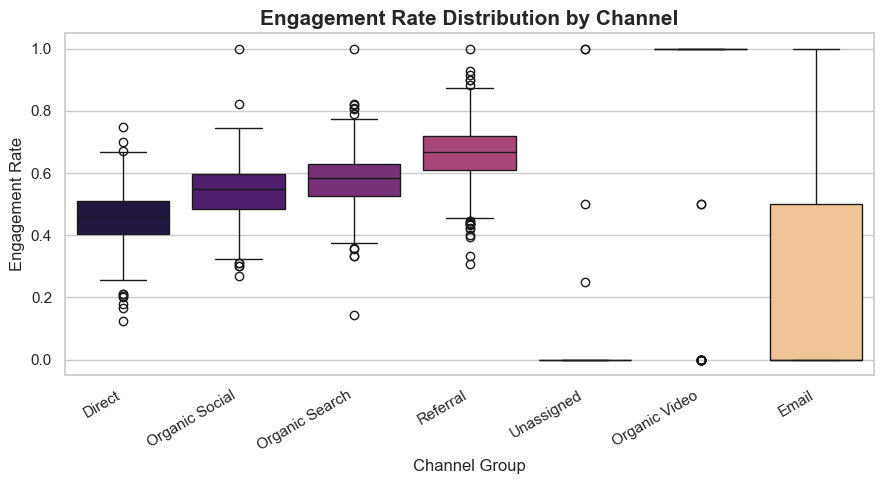

In [12]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="Channel Group",
    y="Engagement Rate",
    palette="magma"
)
plt.title("Engagement Rate Distribution by Channel", fontsize=15, fontweight='bold')
plt.xlabel("Channel Group")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

> **Insight:** A narrow box (low IQR) means engagement is consistent across hours — predictable and reliable. A wide box means engagement fluctuates a lot, possibly depending on time of day or content type. Outliers (dots above/below the whiskers) represent unusually high- or low-engagement hours worth investigating individually.

### 4.5 Engaged vs Non-Engaged Sessions

This stacked-style comparison shows, for each channel, how many sessions were **Engaged**  vs **Non-Engaged** .

This is the single most actionable chart for conversion optimization — a high non-engaged ratio means users are landing and leaving without meaningful interaction.

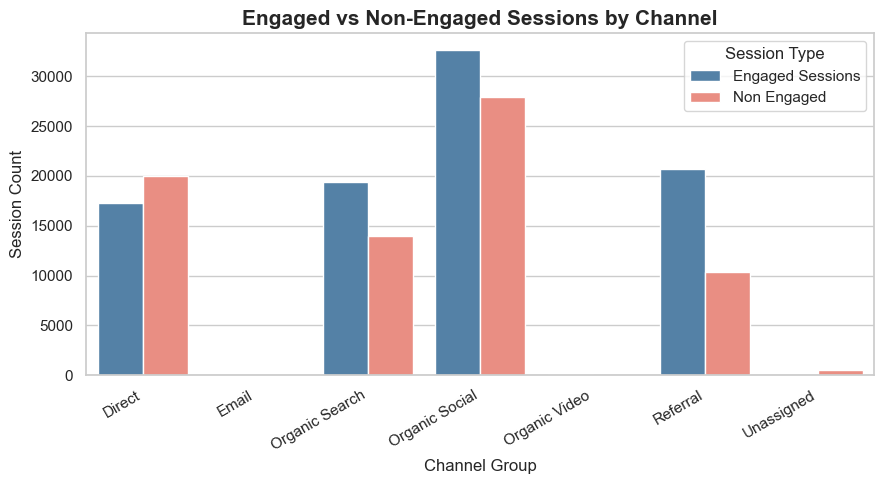

In [13]:
session_df = df.groupby("Channel Group")[["Sessions", "Engaged Sessions"]].sum().reset_index()
session_df["Non Engaged"] = session_df["Sessions"] - session_df["Engaged Sessions"]
session_df_melted = session_df.melt(
    id_vars="Channel Group",
    value_vars=["Engaged Sessions", "Non Engaged"]
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=session_df_melted,
    x="Channel Group",
    y="value",
    hue="variable",
    palette=["steelblue", "salmon"]
)
plt.title("Engaged vs Non-Engaged Sessions by Channel", fontsize=15, fontweight='bold')
plt.xlabel("Channel Group")
plt.ylabel("Session Count")
plt.xticks(rotation=30, ha='right')
plt.legend(title="Session Type")
plt.tight_layout()
plt.show()

> **Insight:** Channels with a high ratio of Non-Engaged sessions are contributing to a poor user experience metric. For example, if Paid Social has many more non-engaged sessions than engaged ones, the ad creative or landing page is not resonating with the audience. Channels where Engaged Sessions dominate are high-quality traffic sources — invest more here.

### 4.6 Traffic Heatmap — Hour × Channel

A heatmap shows traffic intensity (total Sessions) broken down by **hour of the day** (rows) and **Channel Group** (columns). This is a powerful tool for understanding *when* each channel is most active.

This analysis directly informs decisions about:
- When to schedule ad campaigns or social posts
- When to expect server load peaks
- Whether different channels have different usage patterns

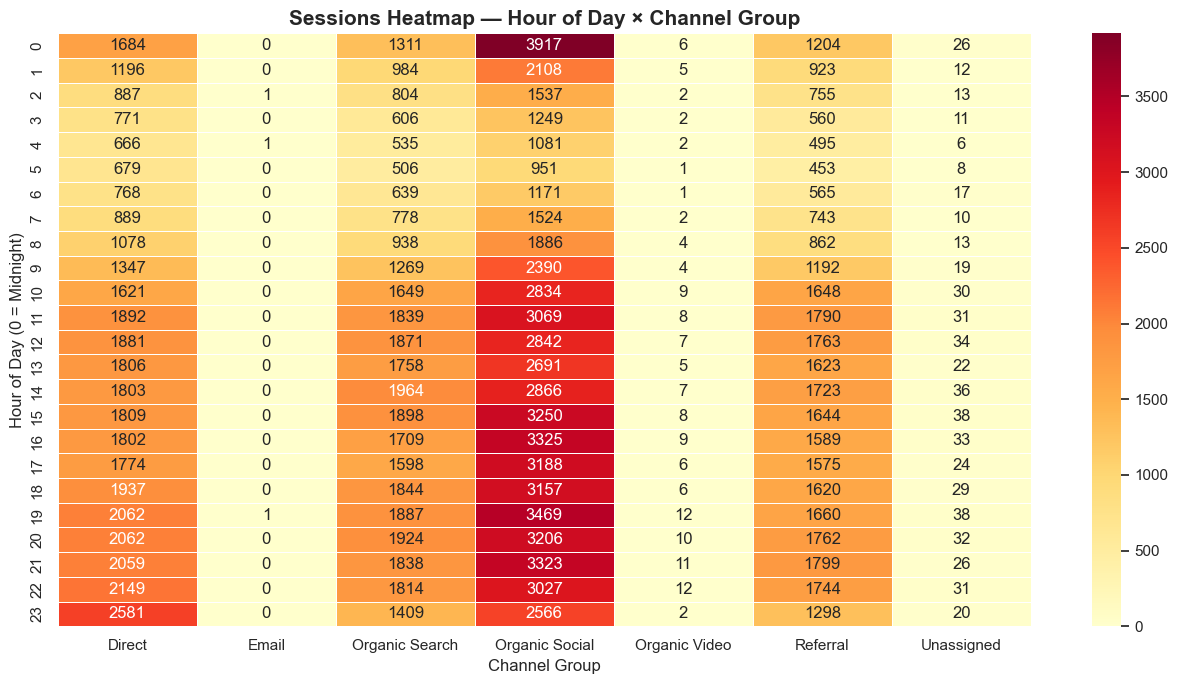

In [14]:
heatmap_data = df.groupby(["hour", "Channel Group"])["Sessions"].sum().unstack().fillna(0)

plt.figure(figsize=(13, 7))
sns.heatmap(
    heatmap_data,
    linewidths=0.5,
    annot=True,
    fmt='.0f',
    cmap="YlOrRd"
)
plt.title("Sessions Heatmap — Hour of Day × Channel Group", fontsize=15, fontweight='bold')
plt.xlabel("Channel Group")
plt.ylabel("Hour of Day (0 = Midnight)")
plt.tight_layout()
plt.show()

> **Insight:** Dark (high-value) cells identify peak traffic windows for each channel. If Organic Search is hottest at 10–11 AM while Direct traffic peaks at 7–8 PM, these audiences behave differently and may need separate content strategies. Late-night dark rows across all channels confirm the typical overnight traffic drop — useful baseline for anomaly detection.

### 4.7 Engagement Rate vs Sessions Over Time

This dual-line chart overlays **Engagement Rate** (quality signal) against **Sessions** (volume signal) over time. Plotting them together reveals the relationship — or tension — between traffic volume and audience quality.

The key question: *When traffic spikes, does engagement hold up — or drop?*

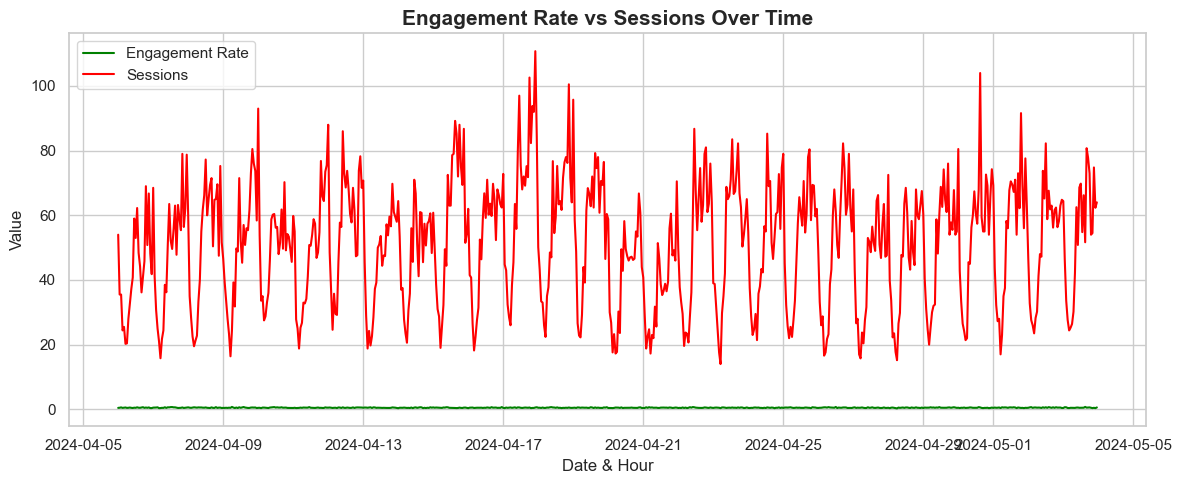

In [15]:
df_plot = df.groupby("DateHour")[["Engagement Rate", "Sessions"]].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(df_plot["DateHour"], df_plot["Engagement Rate"], label="Engagement Rate", color="green", linewidth=1.5)
plt.plot(df_plot["DateHour"], df_plot["Sessions"], label="Sessions", color="red", linewidth=1.5)
plt.title("Engagement Rate vs Sessions Over Time", fontsize=15, fontweight='bold')
plt.xlabel("Date & Hour")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

When sessions increase but engagement rate drops, it often indicates low-quality or low-intent traffic, which is common during paid campaigns or viral spikes.
A positive correlation — where both sessions and engagement rise together — is ideal, as it shows that new users are as engaged as existing ones.
However, if this gap continues even after a campaign ends, it can signal poor traffic quality.

---

## 5. Key Insights & Recommendations

### 🔑 Summary of Findings

| # | Observation | Implication |
|---|-------------|-------------|
| 1 | **Traffic volume varies significantly by channel** | Not all channels are equal — focus investment on high-performing ones |
| 2 | **Engagement time differs by channel despite similar user counts** | Volume ≠ Quality; channels with fewer but more engaged users may deserve higher priority |
| 3 | **Engagement Rate distribution shows variability within channels** | Certain hours or periods drive poor-quality sessions even within a channel |
| 4 | **Non-engaged sessions are a significant fraction for some channels** | Indicates potential landing page mismatch or irrelevant ad targeting |
| 5 | **Hourly heatmap reveals distinct peak windows per channel** | Content publishing and ad scheduling should align with channel-specific peak hours |
| 6 | **Engagement Rate can move inversely to session spikes** | Traffic campaigns may dilute session quality — pair volume campaigns with UX improvements |

### ✅ Actionable Recommendations

1. **Reallocate budget toward high-engagement channels** — even if their user volume is lower, they deliver better downstream conversion rates.
2. **Audit landing pages for high-bounce channels** — the non-engaged session chart pinpoints exactly which channels need UX attention.
3. **Schedule content and campaigns at channel peak hours** — identified from the heatmap analysis.
4. **Monitor Engagement Rate during campaign bursts** — if it drops sharply during a traffic spike, refine audience targeting.
5. **Investigate anomalous spikes** in the time-series — these often reveal campaign wins or tracking errors worth documenting.



